In [29]:
import numpy as np
import os
import cv2
import pickle
import copy

In [2]:
def load_mnist_dataset(dataset, path):
    labels_path = os.path.join(path, 'train')
    labels = os.listdir(labels_path)

    # Lists for samples and labels
    X = []
    y = []
    
    # For each label folder
    for label in labels:
        # Construct the path based on the 'dataset'
        label_dir = os.path.join(path, dataset, label)
        
        # Check if the directory exists
        if not os.path.isdir(label_dir):
            continue
            
        for file in os.listdir(label_dir):
            # Construct the full path to the image file
            file_path = os.path.join(label_dir, file)
            image = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
    
            # And append it and label to the lists
            X.append(image)
            y.append(label)
            
    # Convert the data to proper numpy arrays and return
    return np.array(X), np.array(y).astype('uint8')

def create_data_mnist(path):
    # Load both sets separately
    X, y = load_mnist_dataset('train', path)
    X_test, y_test = load_mnist_dataset('test', path)

    return X, y, X_test, y_test

In [3]:
class LayerDense:
    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0,weight_regularizer_l2=0,
                 bias_regularizer_l1=0, bias_regularizer_l2=0):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

        self.weight_regularizer_l1 = weight_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.bias_regularizer_l2 = bias_regularizer_l2

    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        
        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1
            self.dweights += self.weight_regularizer_l1 * dL1
        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1
        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases
        
        self.dinputs = np.dot(dvalues, self.weights.T)

    def get_parameters(self):
        return self.weights, self.biases

    def set_parameters(self, weights, biases):
        self.weights = weights
        self.biases = biases

class LayerDropout:
    def __init__(self, rate):
        self.rate = 1 - rate
        
    def forward(self, inputs, training):
         self.inputs = inputs
         if not training:
             self.output = inputs.copy()
             return
         self.binary_mask = np.random.binomial(1, self.rate, size=inputs.shape) / self.rate
         self.output = inputs * self.binary_mask
        
    def backward(self, dvalues):
        self.dinputs = dvalues * self.binary_mask

In [4]:
class LayerInput:
    def forward(self, inputs, training):
        self.output = inputs

In [22]:
class ActivationReLu:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0

    def predictions(self, outputs):
        return outputs

# Almost identical to ReLu for shallower networks
class ActivationLeakyRelu:
    def __init__(self, alpha=0.01):
        self.alpha = alpha
        
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = np.maximum(self.alpha * inputs, inputs)
        
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs < 0] *= self.alpha

    def predictions(self, outputs):
        return outputs
        
        
# GeLU does nothing different to the final model. ReLU is enough for small models
class ActivationGeLu:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = 0.5 * inputs * (1 + np.tanh((np.sqrt(2/np.pi) * (inputs + 0.044715 * (inputs ** 3)))))
    
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        x = self.inputs
        k = np.sqrt(2 / np.pi)
        c = 0.044715
        u = k * (x + c * (x**3))
        u_prime = k * (1 + 3 * c * (x**2))
        tanh_u = np.tanh(u)
        sech_u_squared = 1 - (tanh_u**2)
        term1 = 0.5 * (1 + tanh_u)
        term2 = 0.5 * x * sech_u_squared * u_prime
        deriv_GeLu = term1 +term2
        self.dinputs = self.dinputs * deriv_GeLu

    def predictions(self, outputs):
        return outputs

In [6]:
class ActivationSoftmax:
    def forward(self, inputs, training):
        self.inputs = inputs
        # Unnormalized probabilities
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        probabilities = exp_values/ np.sum(exp_values, axis=1, keepdims=True)
        self.output = probabilities

    def backward(self, dvalues):
        self.dinputs = np.empty_like(dvalues)
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)):
            single_output = single_output.reshape(-1, 1)
            jacobian_matrix = np.diagflat(single_output)- np.dot(single_output, single_output.T)
            self.dinputs[index] = np.dot(jacobian_matrix, single_dvalues)

    def predictions(self, outputs):
        return np.argmax(outputs, axis=1)

class ActivationSigmoid:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = 1 / (1 + np.exp(-inputs))

    def backward(self, dvalues):
        self.dinputs = dvalues * (1 - self.output) * self.output

    def predictions(self, outputs):
        return (outputs > 0.5) * 1
    
class ActivationLinear:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = inputs

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()

    def predictions(self, outputs):
        return outputs

In [7]:
class OptimizerSGD:
    def __init__(self, learning_rate=1.0, decay=0., momentum=0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum

    # To call once before any parameter updates
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1 / (1 + self.decay * self.iterations))

    def update_params(self, layer):
        if self.momentum:
            if not hasattr(layer, 'weight_momentums'):
                # If layer does not contain momentum arrays, create them filled with zeros
                layer.weight_momentums = np.zeros_like(layer.weights)
                # Create for the bias as well
                layer.bias_momentums = np.zeros_like(layer.biases)
            weight_updates = self.momentum * layer.weight_momentums - self.current_learning_rate * layer.dweights
            layer.weight_momentums = weight_updates
            bias_updates = self.momentum * layer.bias_momentums - self.current_learning_rate * layer.dbiases
            layer.bias_momentums = bias_updates
        # In case of normal sgd
        else:
            weight_updates = -self.current_learning_rate * layer.dweights
            bias_updates = -self.current_learning_rate * layer.dbiases
        # UPdating weights and biases
        layer.weights += weight_updates
        layer.biases += bias_updates

    def post_update_params(self):
        self.iterations += 1


class OptimizerAdagrad:
    def __init__(self, learning_rate=1., decay=0., epsilon=1e-7):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1 / (1 + self.decay * self.iterations))

    def update_params(self, layer):
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.biases)
        # Updating cache with squared current gradients
        layer.weight_cache += layer.dweights ** 2
        layer.bias_cache += layer.dbiases ** 2

        # SGD update + normalization with square rooted cache
        layer.weights += -self.current_learning_rate * layer.dweights / (np.sqrt(layer.weight_cache) + self.epsilon)
        layer.biases += - self.current_learning_rate * layer.dbiases / (np.sqrt(layer.bias_cache) + self.epsilon)

    def post_update_params(self):
        self.iterations += 1


class OptimizerRMSprop:
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, rho=0.9):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.rho = rho

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1 / (1 + self.decay * self.iterations))

    def update_params(self, layer):
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.biases)
        
        layer.weight_cache = self.rho * layer.weight_cache + (1- self.rho) * layer.dweights ** 2
        layer.bias_cache = self.rho * layer.bias_cache + (1- self.rho) * layer.dbiases ** 2

        layer.weights += -self.current_learning_rate * layer.dweights / (np.sqrt(layer.weight_cache) + self.epsilon)
        layer.biases += -self.current_learning_rate * layer.dbiases / (np.sqrt(layer.bias_cache) + self.epsilon)

    def post_update_params(self):
        self.iterations += 1


class OptimizerAdam:
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.beta_1 = beta_1
        self.beta_2 = beta_2

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1 / (1 + self.decay * self.iterations))

    def update_params(self, layer):
        if not hasattr(layer, 'weight_cache'):
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.biases)
            layer.bias_cache = np.zeros_like(layer.biases)

        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1- self.beta_1) * layer.dweights
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1- self.beta_1) * layer.dbiases

        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1))
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1))

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights ** 2
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1- self.beta_2) * layer.dbiases ** 2

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1))
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1))

        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon)
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon)

    def post_update_params(self):
        self.iterations += 1    

class OptimizerAdamW:
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7,
                 beta_1=0.9, beta_2=0.999, weight_decay=1e-4):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.weight_decay = weight_decay

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * (1 / (1 + self.decay * self.iterations))

    def update_params(self, layer):
        if not hasattr(layer, 'weight_cache'):
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.biases)
            layer.bias_cache = np.zeros_like(layer.biases)

        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1- self.beta_1) * layer.dweights
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1- self.beta_1) * layer.dbiases

        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1))
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1))

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights ** 2
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1- self.beta_2) * layer.dbiases ** 2

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1))
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1))
        
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon)
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon)

        if self.weight_decay > 0:
            layer.weights -= self.current_learning_rate * self.weight_decay * layer.weights

    def post_update_params(self):
        self.iterations += 1

In [8]:
class Loss:
    def regularization_loss(self):
        regularization_loss = 0
        for layer in self.trainable_layers:
            if layer.weight_regularizer_l1 > 0:
                regularization_loss += layer.weight_regularizer_l1 * np.sum(np.abs(layer.weights))
            if layer.weight_regularizer_l2 > 0:
                regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights * layer.weights)
            if layer.bias_regularizer_l1 > 0:
                regularization_loss += layer.bias_regularizer_l1 * np.sum(np.abs(layer.biases))
            if layer.bias_regularizer_l2 > 0:
                regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases * layer.biases)
        return regularization_loss

    def remember_trainable_layers(self, trainable_layers):
        self.trainable_layers = trainable_layers
    
    def calculate(self, output, y, *, include_regularization=False):
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)

        self.accumulated_sum += np.sum(sample_losses)
        self.accumulated_count += len(sample_losses)
        
        if not include_regularization:
            return data_loss
        return data_loss, self.regularization_loss()

    def calculate_accumulated(self, *, include_regularization=False):
        # Mean data loss
        data_loss = self.accumulated_sum / self.accumulated_count
        # IF just data loss, return it
        if not include_regularization:
            return data_loss
        return data_loss, self.regularization_loss()
    # REsetting variables or accumulated loss
    def new_pass(self):
        self.accumulated_sum = 0
        self.accumulated_count = 0
        

class LossCategoricalCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)
        # If categorical labels
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples),
                y_true
            ]
        # If one-hot-encoded labels
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true,
                axis=1
            )
        negative_log_likelihood = -np.log(correct_confidences)
        return negative_log_likelihood

    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        labels = len(dvalues[0])
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        self.dinputs = -y_true / dvalues
        self.dinputs = self.dinputs / samples

class ActivationSoftmaxLossCategorialCrossentropy():
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
            
        self.dinputs = dvalues.copy()
        self.dinputs[range(samples), y_true] -= 1
        self.dinputs = self.dinputs / samples

class LossBinaryCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)
        sample_losses = -(y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
        sample_losses = np.mean(sample_losses, axis=1)
        return sample_losses

    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        outputs = len(dvalues[0])
        clipped_dvalues = np.clip(dvalues, 1e-7, 1-1e-7)
        self.dinputs = -(y_true / clipped_dvalues - (1 - y_true) / (1 - clipped_dvalues)) / outputs
        self.dinputs = self.dinputs / samples

class LossMeanSquaredError(Loss):
    def forward(self, y_pred, y_true):
        sample_losses = np.mean((y_true - y_pred)**2, axis=-1)
        return sample_losses
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        outputs = len(dvalues[0])
        self.dinputs = -2 * (y_true - dvalues) / outputs
        self.dinputs = self.dinputs / samples


class LossMeanAbsoluteError(Loss):
    def forward(self, y_pred, y_true):
        sample_losses = np.mean(np.abs(y_true - y_pred), axis=-1)
        return sample_losses
    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        outputs = len(dvalues[0])
        self.dinputs = np.sign(y_true - dvalues) / outputs
        self.dinputs = self.dinputs / samples

In [9]:
class Accuracy:
    def calculate(self, predictions, y):
        comparisons = self.compare(predictions, y)
        accuracy = np.mean(comparisons)

        self.accumulated_sum += np.sum(comparisons)
        self.accumulated_count += len(comparisons)
        
        return accuracy
    def calculate_accumulated(self):
        accuracy = self.accumulated_sum / self.accumulated_count
        return accuracy

    def new_pass(self):
        self.accumulated_sum = 0
        self.accumulated_count = 0

class AccuracyCategorical(Accuracy):
    def __init__(self, *, binary=False):
        self.binary = binary
    def init(self, y):
        pass
    def compare(self, predictions, y):
        if not self.binary and len(y.shape) == 2:
            y = np.argmax(y, axis=1)
        return predictions == y

class AccuracyRegression(Accuracy):
    def __init__(self):
        self.precision = None

    def init(self, y, reinit=False):
        if self.precision is None or reinit:
            self.precision = np.std(y) / 250

    def compare(self, predictions, y):
        return np.absolute(predictions - y) < self.precision


In [10]:
class Model:
    def __init__(self):
        self.layers = []
        self.softmax_classifier_output = None

    def add(self, layer):
        self.layers.append(layer)

    def set(self, *, loss=None, optimizer=None, accuracy=None):
        if loss is not None:
            self.loss = loss
        if optimizer is not None:
            self.optimizer = optimizer
        if accuracy is not None:
            self.accuracy = accuracy

    def finalize(self):
        self.input_layer = LayerInput()
        layer_count = len(self.layers)
        self.trainable_layers = []
        
        for i in range(layer_count):
            # If it's the first layer, the previous layer object is the input layer
            if i == 0:
                self.layers[i].prev = self.input_layer
                self.layers[i].next = self.layers[i+1]
            elif i < layer_count - 1:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.layers[i+1]
            else:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.loss
                self.output_layer_activation = self.layers[i]

            if hasattr(self.layers[i], 'weights'):
                self.trainable_layers.append(self.layers[i])
            if self.loss is not None:
                self.loss.remember_trainable_layers(
                    self.trainable_layers
                )

        if isinstance(self.layers[-1], ActivationSoftmax) and isinstance(self.loss, LossCategoricalCrossentropy):
            self.softmax_classifier_output = ActivationSoftmaxLossCategorialCrossentropy()

    def train(self, X, y, *, epochs=1, batch_size=None, print_every=1, validation_data=None):
        self.accuracy.init(y)

        # Default value if batch size is not being set
        train_steps = 1

        # If there is validation data passed, set default number of steps for validation as well
        if validation_data is not None:
            validation_steps = 1

            # For better readability
            X_val, y_val = validation_data
        
        # Calculate number of steps
        if batch_size is not None:
            train_steps = len(X) // batch_size
            if train_steps * batch_size < len(X):
                train_steps += 1
            if validation_data is not None:
                validation_steps = len(X_val) // batch_size
                if validation_steps * batch_size < len(X_val):
                    validation_steps += 1
            
        for epoch in range(1, epochs+1):
            print(f'epoch: {epoch}')

            # Reset accumulated values in loss and accuracy objects
            self.loss.new_pass()
            self.accuracy.new_pass()
            
            # Create a copy to shuffle (or shuffle indices)
            X_shuffled = X.copy()
            y_shuffled = y.copy()
            
            # Create a permutation of indices
            keys = np.array(range(len(X_shuffled)))
            np.random.shuffle(keys)
            
            # Reorder X and y based on shuffled keys
            X_shuffled = X_shuffled[keys]
            y_shuffled = y_shuffled[keys]

            # Iterate over steps
            for step in range(train_steps):
                if batch_size is None:
                    # Note: You had a typo here, 'x' instead of 'X'
                    batch_X = X_shuffled
                    batch_y = y_shuffled
                else:
                    batch_X = X_shuffled[step*batch_size: (step+1) * batch_size]
                    batch_y = y_shuffled[step*batch_size: (step+1) * batch_size]
                    
                output = self.forward(batch_X, training=True)
                data_loss, regularization_loss = self.loss.calculate(output, batch_y, include_regularization=True)
                loss = data_loss + regularization_loss
                predictions = self.output_layer_activation.predictions(output)
                accuracy = self.accuracy.calculate(predictions, batch_y)
            
                self.backward(output, batch_y)
            
                self.optimizer.pre_update_params()
                for layer in self.trainable_layers:
                    self.optimizer.update_params(layer)
                self.optimizer.post_update_params()

                if not step % print_every or step == train_steps - 1:
                    print(f'step: {step}, ' +
                          f'acc: {accuracy:.3f}, ' +
                          f'loss: {loss:.3f} (' +
                          f'data_loss: {data_loss:.3f}, ' +
                          f'reg_loss: {regularization_loss:.3f}), ' +
                          f'lr: {self.optimizer.current_learning_rate}')
            
            # Get and print epoch loss and accuracy
            epoch_data_loss, epoch_regularization_loss = self.loss.calculate_accumulated(include_regularization=True)
            epoch_loss = epoch_data_loss + epoch_regularization_loss
            epoch_accuracy = self.accuracy.calculate_accumulated()

            print(f'training, ' +
                  f'acc: {epoch_accuracy:.3f}, ' +
                  f'loss: {epoch_loss:.3f} (' +
                  f'data_loss: {epoch_data_loss:.3f}, ' +
                  f'reg_loss: {epoch_regularization_loss:.3f}), ' +
                  f'lr: {self.optimizer.current_learning_rate}')
        
            if validation_data is not None:
                self.evaluate(*validation_data, batch_size=batch_size)
    
    def evaluate(self, X_val, y_val, *, batch_size=None):
        validation_steps = 1
        if batch_size is not None:
            validation_steps = len(X_val) // batch_size
            if validation_steps * batch_size < len(X_val):
                validation_steps += 1
        self.loss.new_pass()
        self.accuracy.new_pass()

        for step in range(validation_steps):
            if batch_size is None:
                batch_X = X_val
                batch_y = y_val
            else:
                batch_X = X_val[step*batch_size: (step+1) * batch_size]
                batch_y = y_val[step*batch_size: (step+1) * batch_size]
            
            output = self.forward(batch_X, training=False)
            self.loss.calculate(output, batch_y)
            predictions = self.output_layer_activation.predictions(output)
            self.accuracy.calculate(predictions, batch_y)
        
        validation_loss = self.loss.calculate_accumulated()
        validation_accuracy = self.accuracy.calculate_accumulated()
        print(f'validation, ' + 
              f'acc: {validation_accuracy:.3f}, ' + 
              f'loss: {validation_loss:.3f}')
        
    def forward(self, X, training):
        # Call forward method on the input layer, this will set the output property that the first layer in "prev" object is expecting.
        self.input_layer.forward(X, training)
        for layer in self.layers:
            layer.forward(layer.prev.output, training)
        # Now, layer is the last object from the list
        return layer.output

    def backward(self, output, y):
        if self.softmax_classifier_output is not None:
            self.softmax_classifier_output.backward(output, y)
            self.layers[-1].dinputs = self.softmax_classifier_output.dinputs
            for layer in reversed(self.layers[:-1]):
                layer.backward(layer.next.dinputs)
            return
        self.loss.backward(output, y)
        for layer in reversed(self.layers):
            layer.backward(layer.next.dinputs)

    def get_parameters(self):
        parameters = []

        for layer in self.trainable_layers:
            parameters.append(layer.get_parameters())

        return parameters

    def set_parameters(self, parameters):
        for parameter_set, layer in zip(parameters, self.trainable_layers):
            layer.set_parameters(*parameter_set)

    def save_parameters(self, path):
        with open(path, 'wb') as f:
            pickle.dump(self.get_parameters(), f)

    def load_parameters(self, path):
        with open(path, 'rb') as f:
            self.set_parameters(pickle.load(f))

    def save(self, path):
        # Copy the whole model
        model = copy.deepcopy(self)
        # REset accumulated values in loss and accuracy objects
        model.loss.new_pass()
        model.accuracy.new_pass()
        # Remove data from input layer and gradients from loss object
        model.input_layer.__dict__.pop('output', None)
        model.loss.__dict__.pop('dinputs', None)
        
        for layer in model.layers:
            for property in ['inputs', 'output', 'dinputs', 'dweights', 'dbiases']:
                layer.__dict__.pop(property, None)
        with open(path, 'wb') as f:
            pickle.dump(model, f)

    @staticmethod
    def load(path):
        with open(path, 'rb') as f:
            model = pickle.load(f)
        return model

    def predict(self, X, *, batch_size=None):
        prediction_steps = 1
        if batch_size is not None:
            prediction_steps = len(X) // batch_size
            if prediction_steps * batch_size < len(X):
                prediction_steps += 1
        output = []
        for step in range(prediction_steps):
            if batch_size is None:
                batch_X = X
            else:
                batch_X = X[step*batch_size:(step+1)*batch_size]
            batch_output = self.forward(batch_X, training=False)
            output.append(batch_output)
        return np.vstack(output)


In [23]:
X, y, X_test, y_test = create_data_mnist('fashion_mnist_images/')

keys = np.array(range(X.shape[0]))
np.random.shuffle(keys)
X = X[keys]
y = y[keys]

X = (X.reshape(X.shape[0], -1).astype(np.float32) - 127.5) / 127.5
X_test = (X_test.reshape(X_test.shape[0], -1).astype(np.float32) - 127.5) / 127.5

# Instantiate model
model = Model()

model.add(LayerDense(X.shape[1], 256))
model.add(ActivationLeakyRelu())
model.add(LayerDropout(0.5))

model.add(LayerDense(256, 256, weight_regularizer_l2=5e-4, bias_regularizer_l2=5e-4))
model.add(ActivationLeakyRelu())
model.add(LayerDropout(0.5))

model.add(LayerDense(256, 256, weight_regularizer_l2=5e-4, bias_regularizer_l2=5e-4))
model.add(ActivationLeakyRelu())
model.add(LayerDropout(0.5))

model.add(LayerDense(256, 10))
model.add(ActivationSoftmax())

model.set(
    loss=LossCategoricalCrossentropy(),
    optimizer=OptimizerAdamW(decay=5e-4),
    accuracy=AccuracyCategorical()
)

model.finalize()

model.train(X, y, validation_data=(X_test, y_test), epochs=20, batch_size=128, print_every=100)
model.evaluate(X_test, y_test)
model.save('fashion_mnist.model')


epoch: 1
step: 0, acc: 0.078, loss: 2.309 (data_loss: 2.303, reg_loss: 0.007), lr: 0.001
step: 100, acc: 0.703, loss: 0.908 (data_loss: 0.893, reg_loss: 0.016), lr: 0.0009523809523809524
step: 200, acc: 0.695, loss: 0.839 (data_loss: 0.816, reg_loss: 0.022), lr: 0.0009090909090909091
step: 300, acc: 0.695, loss: 0.736 (data_loss: 0.711, reg_loss: 0.026), lr: 0.0008695652173913045
step: 400, acc: 0.781, loss: 0.622 (data_loss: 0.594, reg_loss: 0.028), lr: 0.0008333333333333334
step: 468, acc: 0.750, loss: 0.677 (data_loss: 0.647, reg_loss: 0.029), lr: 0.0008103727714748784
training, acc: 0.691, loss: 0.826 (data_loss: 0.797, reg_loss: 0.029), lr: 0.0008103727714748784
validation, acc: 0.803, loss: 0.526
epoch: 2
step: 0, acc: 0.789, loss: 0.695 (data_loss: 0.665, reg_loss: 0.029), lr: 0.0008100445524503849
step: 100, acc: 0.820, loss: 0.494 (data_loss: 0.462, reg_loss: 0.032), lr: 0.0007785130400934216
step: 200, acc: 0.797, loss: 0.634 (data_loss: 0.601, reg_loss: 0.033), lr: 0.0007493

In [24]:
X, y, X_test, y_test = create_data_mnist('fashion_mnist_images')
X_test = (X_test.reshape(X_test.shape[0], -1).astype(np.float32) - 127.5) / 127.5

model = Model.load('fashion_mnist.model')
confidences = model.predict(X_test[:5])
predictions = model.output_layer_activation.predictions(confidences)
print(predictions)

[3 3 3 3 3]


In [25]:
print(y_test[:5])

[3 3 3 3 3]


In [26]:
fashion_mnist_labels = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}
for prediction in predictions:
    print(fashion_mnist_labels[prediction])

Dress
Dress
Dress
Dress
Dress


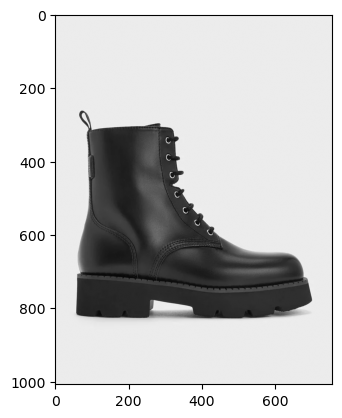

In [27]:
image_data = cv2.imread('boots.png', cv2.IMREAD_GRAYSCALE)
import matplotlib.pyplot as plt
plt.imshow(image_data, cmap='gray')
plt.show()

In [30]:
# Read image and convert to grayscale
image_data = cv2.imread('boots.png', cv2.IMREAD_GRAYSCALE)
# Resize to the same size as Fashion MNIST images
image_data = cv2.resize(image_data, (28, 28))
# Inverts image colors if necessary
image_mean = np.mean(image_data, axis=1)
inverting_indices = np.where(image_mean < 127.5)
image_data[inverting_indices] = 255 - image_data[inverting_indices]
# Reshape and scale pixel data
image_data = (image_data.reshape(1, -1).astype(np.float32) - 127.5) / 127.5
# Load the model
model = Model.load('fashion_mnist.model')
# Predict on the image
confidences = model.predict(image_data)
# Get prediction instead of confidence levels
predictions = model.output_layer_activation.predictions(confidences)
# Get label name from label index
prediction = fashion_mnist_labels[predictions[0]]
print(prediction)

Ankle boot


In [52]:
def one_d_convolution(inp, kernel, stride=1, padding=None):
    inp = np.asarray(inp)
    kernel = np.asarray(kernel)
    if padding is not None:
        inp = np.concatenate([np.zeros((padding,), dtype=int), inp, np.zeros((padding,), dtype=int)])
    print(inp)
    output = []
    kernel_len = len(kernel)
    out_dim = len(inp) - kernel_len + 1
    for i in range(0, out_dim, stride):
        kernel_mul = inp[i:i+kernel_len] * kernel
        kernel_mul_sum = np.sum(kernel_mul)
        output.append(kernel_mul_sum)
    return np.array(output)

In [53]:
inp = [1, 2, 3, 4, 5]
kernel = [1, 2]

In [55]:
one_d_convolution(inp, kernel, 1, 3)

[0 0 0 1 2 3 4 5 0 0 0]


array([ 0,  0,  2,  5,  8, 11, 14,  5,  0,  0])